# Pattern: Buy and Sell (Find Maximum Profit)

## Core logic

* Buy at the minimum price & sell at the maximum price to maximize the profit.
* ***Tracking Minimum Value & Find Maximum Profit***
* At most one transaction is allowed at a time: either buy or sell
* Stock must be bought first, before being sold.

## Algorithm/Approach

1. Initialize

    * `min_price = infinity`
    * `max_profit = 0`

2. For each price:

    * if `price < min_price` then update `min_price = price`
    * else:
        * compute possible `profit = (price - min_price)`
        * update `max_profit` if this profit is better

3. Return max_profit

# Problem 1: Buy and Sell - Only One transaction allowed

Given an array `prices[]` of length `N`, representing the prices of the stocks on different days, the task is to find the **maximum profit** possible for **buying and selling the stocks on different days** using transactions where **at most one transaction is allowed**.

**Note:** Stock must be bought before being sold.

**Input:** `prices[] = {7, 1, 5, 3, 6, 4]`

**Output:** `5`

**Explanation:**
* The lowest price of the stock is on the **2nd day**, i.e., `price = 1`.
* Starting from the **2nd day**, the highest price of the stock is witnessed on the 5th day, i.e., `price = 6`. 
* Therefore, maximum possible `profit = 6 – 1 = 5`.


## Solution 1

In [3]:
def max_profit(stock_prices):
    
    min_price = stock_prices[0]
    max_profit = -1 # since profit cannot be negative
    
    for i in range(len(stock_prices)):
        
        # Tracking Minimum Price
        if stock_prices[i] < min_price:
            min_price = stock_prices[i]
        else:
            # Finding maximum profit
            profit = stock_prices[i] - min_price
            max_profit = max(max_profit,profit)
    
    return max_profit


input_stock_price = [7, 1, 5, 3, 6, 4]
print(max_profit(input_stock_price))

5


**Time Complexity**: `O(n)`

**Space Complexity**: `O(1)`

# Problem 2: Buy and Sell - Unlimited transactions allowed (can hold at most one share at a time)

Given a list containing future predictions of share prices, find the **maximum profit** earned by **buying and selling shares any number of times** with the constraint that **a new transaction can only start after the previous transaction is complete**, i.e., we can only **hold at most one share at a time**.

**For example:**

**Stock Prices:** `[1, 5, 2, 3, 7, 6, 4, 5]`

**Output**: 10

**Explanation**:
* Total profit earned is 10
* Buy on day 1 and sell on day 2
* Buy on day 3 and sell on day 5
* Buy on day 7 and sell on day 8


## Intuition Behind The Pattern

Stock prices are fluctuating up and down constantly.

We have two options:
* Option A: One big transaction
* Option B: Many small transactions

**Option B is optimal.**
* Instead of one transaction, that is, buy at the lowest & sell at the highest peak.
* We can maximize the profit by capturing every small rise in the fluctuating market.
* That is, add all profit from every upward trend, capture every profitable jump, and ignore all dips.

**Pattern: Capture Every Upward Movement in a Fluctuating Market**

If the price graph looks like mountains and valleys:

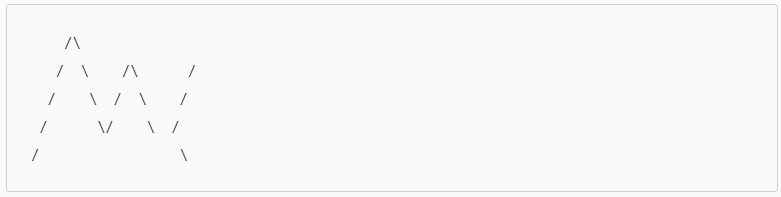

You want to profit from every rise, no matter how small, while avoiding the losses during falls.
* Buy at every valley
* Sell at every peak

> ***You can only hold one share at a time, so buy exactly before a rise and sell before a fall.***

## Key Insight (Most Important)

**If tomorrow’s price is higher than today’s, buy today and sell tomorrow.**

In other words:
* Every time price goes up, profit = difference
* Every time price goes down, we skip it

> ***You can only hold one share at a time, so buy exactly before a rise and sell before a fall.***

## Why This Greedy Pattern Is Optimal

When unlimited transactions are allowed and prices fluctuate, ***the maximum profit equals the sum of all positive consecutive differences***.

This greedy strategy is optimal because:
* You exploit every rise
* You avoid every fall
* You guarantee maximum cumulative gain
* Any long rise is just multiple small rises added together

## Alogrithm/Approach

> ***You can only hold one share at a time, so buy exactly before a rise and sell before a fall.


**Buying Logic**: Goal is to buy at the lowest point in a decreasing trend, before an upward/rising trend starts.

```python
# If tomorrow’s price is higher than today’s, then buy today.
# Otherwise, again check tomorrow with the same logic.

stock_prices[i] < stock_prices[i-1]
```

**Selling Logic**: Goal is to sell at the peak in an increasing trend, before a downward/falling trend starts.

```python
# If tomorrow’s price is higher than today’s, then sell tomorrow.
# Otherwise, again check tomorrow with the same logic.

previous_stock_price <= current_stock_price > next_stock_price
```

**Problem Constraints**:
* Buying and selling shares any number of times.
* Can hold at most one share at a time. That is, a new transaction can only start after the previous transaction is complete, which means ***one cannot buy a new stock until the existing stock is sold***. 

## Solution 2

In [8]:
def maximize_profit(stock_prices):
    
    # keep track of the maximum profit gained
    profit = 0

    # initialize the local minimum to the first element's index
    buying_index = 0

    # start from the second element
    for i in range(1, len(stock_prices)):

        # update the local minimum if a decreasing sequence is found
        if stock_prices[i] < stock_prices[i-1]:
            buying_index = i

        # sell shares if the current element is the peak
        # that is, previous_price <= current_price > next_price
        if ((stock_prices[i-1] <= stock_prices[i])
                and (i + 1 == len(stock_prices) or stock_prices[i] > stock_prices[i+1])): # i + 1 == len(stock_prices) to prevent index error for stock_prices[i+1]
            profit += (stock_prices[i] - stock_prices[buying_index])
            print(f"Buy on day {buying_index+1} and sell on day {i+1}")

    return profit


stock_prices = [1, 5, 2, 3, 7, 6, 4, 5]
print(maximize_profit(stock_prices))

Buy on day 1 and sell on day 2
Buy on day 3 and sell on day 5
Buy on day 7 and sell on day 8
10


**Time Complexity**: `O(n)`

**Space Complexity**: `O(1)`